# **Projeto: Simulação de Opinião Pública com Modelos de Linguagem (LLMs)**
## *“Percepção dos paulistanos acerca de questões relacionadas às mulheres.”*

A opinião pública é um importante instrumento para compreender percepções, valores e comportamentos presentes em uma sociedade. Pesquisas de opinião permitem observar como diferentes grupos sociais se posicionam diante de temas relevantes, além de possibilitarem análises sobre desigualdades, percepções coletivas e padrões de resposta associados a características sociodemográficas.

Nos últimos anos, os Modelos de Linguagem de Grande Escala, conhecidos como LLMs, passaram a ser explorados em tarefas que vão além da geração de texto, incluindo simulações sociais, apoio à tomada de decisão e análise de comportamento. Nesse contexto, surge o interesse em investigar se esses modelos são capazes de simular respostas de questionários de opinião pública a partir de informações sobre o perfil dos respondentes.

Este trabalho tem como base a pesquisa `CESOP 04833`, intitulada **“Percepção dos paulistanos acerca de questões relacionadas às mulheres”**, que reúne dados de entrevistados da cidade de São Paulo sobre temas como divisão de tarefas domésticas, assédio, violência e desigualdades de gênero. A escolha dessa pesquisa se justifica pela relevância social do tema e pela possibilidade de analisar questões associadas às experiências e percepções de diferentes grupos da população.

### Grupo: Mulheres

In [ ]:
Aluno1 = '10416616, Beatriz Lima de Moura' #@param {type:"string"}
Aluno2 = '10417646, Giovana Simões Franco' #@param {type:"string"}
Aluno3 = '10417672, Julia Santos Oliveira' #@param {type:"string"}
Aluno4 = '10418318, Larissa Yuri Sato' #@param {type:"string"}

## Pesquisa utilizada: CESOP 04833

A pesquisa contém respostas individuais de entrevistados, acompanhadas por variáveis sociodemográficas, como sexo, idade, escolaridade, renda, religião, raça/cor, ocupação, classe social e região da cidade. Essas informações são utilizadas para construir perfis de respondentes que serão fornecidos ao modelo de linguagem durante a etapa de simulação.

Para este trabalho, foram selecionadas duas questões:

A **Questão 1**, representada pela variável `P1`, pergunta ao entrevistado como ele definiria a divisão dos afazeres domésticos em sua casa. Essa questão possui múltiplas alternativas e permite observar percepções sobre a responsabilidade de homens e mulheres nas tarefas domésticas.

A **Questão 4**, representada pela variável `P4`, pergunta em qual local a entrevistada acredita correr maior risco de sofrer algum tipo de assédio. Essa questão foi aplicada somente a mulheres, portanto, a análise dessa variável considera apenas respondentes do sexo feminino.

A seleção dessas perguntas permite avaliar o desempenho do modelo em dois tipos de situação: uma questão aplicada ao conjunto geral dos entrevistados e uma questão direcionada a um recorte específico da amostra.

## Desenvolvimento

In [ ]:
# 1. Instalação das dependências
!pip -q install pyreadstat pandas numpy scikit-learn matplotlib scipy transformers accelerate bitsandbytes sentencepiece tqdm

In [ ]:
# 2. Imports
import os, re, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

SEED = 42
np.random.seed(SEED)

In [ ]:
# 3. Upload e extração do ZIP
from google.colab import files
uploaded = files.upload()
zip_name = next(iter(uploaded.keys()))

DATA_DIR = Path('/content/cesop_04833')
DATA_DIR.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DATA_DIR)
list(DATA_DIR.iterdir())

Saving 04833 PERCEPÇÃO DOS PAULISTANOS ACERCA DE QUESTÕES RELACIONADAS ÀS MULHERES.zip to 04833 PERCEPÇÃO DOS PAULISTANOS ACERCA DE QUESTÕES RELACIONADAS ÀS MULHERES (2).zip


[PosixPath('/content/cesop_04833/TF_04833.pdf'),
 PosixPath('/content/cesop_04833/04833.SAV'),
 PosixPath('/content/cesop_04833/quest_04833.pdf')]

In [ ]:
# 4. Leitura do banco .SAV
sav_path = DATA_DIR / '04833.SAV'
df, meta = pyreadstat.read_sav(sav_path, apply_value_formats=False)
print(df.shape)
df.head()

(800, 37)


,SEXO,IDADE,FX_ID,ESCOLARIDADE,P1,P2_1,P2_2,P2_3,P3_1,P3_2,...,RELIGIAO,RENDA1,RENDA2,OCUPACAO,CLASSE,REGIAO,ID,TIPO_COLETA,AMOSTRA,FATOR_POND
0,1.0,73.0,5.0,16.0,3.0,2.0,7.0,6.0,7.0,4.0,...,1.0,4.0,4.0,1.0,2.0,2.0,194317546.0,4.0,3.0,0.503997
1,2.0,41.0,3.0,16.0,3.0,2.0,7.0,3.0,99.0,NaN,...,1.0,6.0,6.0,2.0,4.0,5.0,194318072.0,4.0,3.0,2.046792
2,1.0,62.0,5.0,16.0,5.0,99.0,NaN,NaN,99.0,NaN,...,1.0,4.0,3.0,1.0,3.0,8.0,194318499.0,4.0,3.0,0.888013
3,1.0,71.0,5.0,15.0,5.0,99.0,NaN,NaN,99.0,NaN,...,1.0,5.0,5.0,2.0,4.0,6.0,194319209.0,4.0,3.0,0.483198
4,1.0,42.0,3.0,16.0,5.0,2.0,10.0,3.0,1.0,7.0,...,1.0,4.0,4.0,1.0,3.0,6.0,194319391.0,4.0,3.0,1.042582


In [ ]:
# 5. Metadados e rótulos
value_labels = meta.variable_value_labels
for var in ['SEXO','FX_ID','ESCOLARIDADE','P1','P4','RACA','RELIGIAO','RENDA1','RENDA2','OCUPACAO','CLASSE','REGIAO','AMOSTRA']:
    print('\n', var)
    print(value_labels.get(var, 'sem labels'))


 SEXO
{1.0: 'Masculino', 2.0: 'Feminino'}

 FX_ID
{1.0: '16 a 24', 2.0: '25 a 34', 3.0: '35 a 44', 4.0: '45 a 59', 5.0: '60 e mais'}

 ESCOLARIDADE
{1.0: 'Analfabeto', 2.0: 'Sabe ler/escrever, mas não cursou escola', 3.0: 'Pré-escola (ou 1º ano do fundamental)', 4.0: '1ª série (ou 2º ano) do fundamental / 1ª série do antigo primário', 5.0: '2ª série (ou 3º ano) do fundamental/ 2ª série do antigo primário', 6.0: '3ª série (ou 4º ano) do fundamental/ 3ª série do antigo primário', 7.0: '4ª série (ou 5º ano) do fundamental/ 4ª ou 5ª série do antigo primário', 8.0: '5ª série (ou 6º ano) do fundamental / 1ª série do antigo ginásio', 9.0: '6ª série (ou 7º ano) do fundamental / 2ª série do antigo ginásio', 10.0: '7ª série (ou 8º ano) do fundamental / 3ª série do antigo ginásio', 11.0: '8ª série (ou 9º ano) do fundamental / 4ª série do antigo ginásio', 12.0: '1ª série do ensino médio / 1ª série do antigo colegial', 13.0: '2ª série do ensino médio / 2ª série do antigo colegial', 14.0: '3ª série

In [ ]:
# 6. Funções auxiliares
def label_value(var, code):
    if pd.isna(code):
        return 'Não informado'
    labels = value_labels.get(var, {})
    return labels.get(float(code), str(code))

def simple_distribution(series):
    return series.value_counts(normalize=True, dropna=False).sort_index()

def weighted_distribution(data, target_col, weight_col='FATOR_POND'):
    tmp = data[[target_col, weight_col]].dropna()
    dist = tmp.groupby(target_col)[weight_col].sum()
    return dist / dist.sum()

def total_variation_distance(p, q):
    idx = sorted(set(p.index).union(set(q.index)))
    p2 = p.reindex(idx, fill_value=0).astype(float)
    q2 = q.reindex(idx, fill_value=0).astype(float)
    return 0.5 * np.abs(p2 - q2).sum()

def js_distance(p, q):
    idx = sorted(set(p.index).union(set(q.index)))
    p2 = p.reindex(idx, fill_value=0).astype(float).values
    q2 = q.reindex(idx, fill_value=0).astype(float).values
    return float(jensenshannon(p2, q2, base=2))

def plot_distribution_comparison(real, llm, rf, title):
    idx = sorted(set(real.index).union(set(llm.index)).union(set(rf.index)))
    comp = pd.DataFrame({
        'Real': real.reindex(idx, fill_value=0),
        'LLM': llm.reindex(idx, fill_value=0),
        'Random Forest': rf.reindex(idx, fill_value=0)
    })
    ax = comp.plot(kind='bar', figsize=(11, 5))
    ax.set_title(title)
    ax.set_xlabel('Código da resposta')
    ax.set_ylabel('Proporção')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return comp

In [ ]:
# 7. Seleção das variáveis preditoras
feature_cols = ['SEXO','IDADE','FX_ID','ESCOLARIDADE','RACA','RELIGIAO','RENDA1','RENDA2','OCUPACAO','CLASSE','REGIAO','AMOSTRA']

base_p1 = df[feature_cols + ['P1','FATOR_POND']].dropna(subset=['P1']).copy()
base_p4 = df[df['SEXO'] == 2][feature_cols + ['P4','FATOR_POND']].dropna(subset=['P4']).copy()

print('Base P1:', base_p1.shape)
print('Base P4 apenas mulheres:', base_p4.shape)
print('\nDistribuição P1 ponderada:')
print(weighted_distribution(base_p1, 'P1'))
print('\nDistribuição P4 ponderada:')
print(weighted_distribution(base_p4, 'P4'))

Base P1: (800, 14)
Base P4 apenas mulheres: (429, 14)

Distribuição P1 ponderada:
P1
1.0     0.091425
2.0     0.017175
3.0     0.323585
4.0     0.027891
5.0     0.405989
96.0    0.038603
97.0    0.091913
99.0    0.003419
Name: FATOR_POND, dtype: float64

Distribuição P4 ponderada:
P4
1.0     0.366084
2.0     0.078087
3.0     0.243327
4.0     0.102537
5.0     0.060518
6.0     0.015834
7.0     0.026491
99.0    0.107122
Name: FATOR_POND, dtype: float64


In [ ]:
# 8. Amostras para simulação LLM
N_SAMPLE = 200
sample_p1 = base_p1.sample(n=min(N_SAMPLE, len(base_p1)), random_state=SEED).reset_index(drop=True)
sample_p4 = base_p4.sample(n=min(N_SAMPLE, len(base_p4)), random_state=SEED).reset_index(drop=True)
print(sample_p1.shape, sample_p4.shape)

(200, 14) (200, 14)


In [ ]:
# 9. Prompts
P1_OPTIONS = {
    1:'São de responsabilidade apenas das mulheres',
    2:'São de responsabilidade apenas dos homens',
    3:'São de responsabilidade de homens e mulheres, mas as mulheres fazem a maior parte',
    4:'São de responsabilidade de homens e mulheres, mas os homens fazem a maior parte',
    5:'São divididos igualmente entre os homens e mulheres',
    96:'Mora apenas com pessoas do mesmo sexo',
    97:'Mora sozinho(a)',
    99:'Não respondeu'
}
P4_OPTIONS = {
    1:'No transporte público',
    2:'Nos pontos de ônibus',
    3:'Na rua',
    4:'Em bares e casas noturnas',
    5:'No transporte particular como Táxi, UBER, Cabify, EasyTaxi e 99',
    6:'No trabalho',
    7:'No ambiente familiar',
    99:'Não sabe/ Não respondeu'
}

def respondent_profile(row):
    return f"""
- Sexo: {label_value('SEXO', row['SEXO'])}
- Idade: {int(row['IDADE']) if not pd.isna(row['IDADE']) else 'Não informado'}
- Faixa etária: {label_value('FX_ID', row['FX_ID'])}
- Escolaridade: {label_value('ESCOLARIDADE', row['ESCOLARIDADE'])}
- Cor ou raça: {label_value('RACA', row['RACA'])}
- Religião: {label_value('RELIGIAO', row['RELIGIAO'])}
- Renda individual: {label_value('RENDA1', row['RENDA1'])}
- Renda familiar: {label_value('RENDA2', row['RENDA2'])}
- Ocupação: {label_value('OCUPACAO', row['OCUPACAO'])}
- Classe social: {label_value('CLASSE', row['CLASSE'])}
- Região da cidade: {label_value('REGIAO', row['REGIAO'])}
""".strip()

def build_prompt_p1(row):
    options = '\n'.join([f'{k} - {v}' for k, v in P1_OPTIONS.items()])
    return f"""Você está simulando a resposta de uma pessoa entrevistada em uma pesquisa de opinião pública na cidade de São Paulo.

Perfil da pessoa:
{respondent_profile(row)}

Pergunta:
Como você definiria a divisão dos afazeres domésticos em sua casa, como lavar a louça, lavar a roupa, pôr o lixo para fora, limpar a casa, preparar as refeições, entre outros?

Escolha exatamente uma alternativa:
{options}

Responda apenas com o código numérico da alternativa escolhida. Não explique."""

def build_prompt_p4(row):
    options = '\n'.join([f'{k} - {v}' for k, v in P4_OPTIONS.items()])
    return f"""Você está simulando a resposta de uma mulher entrevistada em uma pesquisa de opinião pública na cidade de São Paulo.

Perfil da pessoa:
{respondent_profile(row)}

Pergunta:
Em qual desses locais você acredita que mais corre o risco de sofrer algum tipo de assédio?

Escolha exatamente uma alternativa:
{options}

Responda apenas com o código numérico da alternativa escolhida. Não explique."""

def extract_code(text, valid_codes):
    text = str(text).strip()
    matches = re.findall(r'\b\d+\b', text)
    for m in matches:
        code = int(m)
        if code in valid_codes:
            return code
    return 99

**Metodologia e Escolhas Técnicas**

Para a etapa de simulação generativa, optamos pela utilização do modelo `Qwen/Qwen2.5-0.5B-Instruct`. A escolha deste modelo se justifica por ser uma tecnologia de pesos abertos (*open-weights*), altamente otimizada e capaz de ser executada localmente utilizando os recursos de GPU gratuitos do Google Colab (T4 GPU).

O processo de inferência foi realizado na abordagem *Zero-Shot*, na qual o modelo recebe um *prompt* estruturado contendo o perfil sociodemográfico detalhado do respondente (idade, sexo, escolaridade, classe, região, etc.) e a pergunta exata da pesquisa, devendo retornar apenas a alternativa escolhida.

Para estabelecer uma base de comparação sólida (*Baseline*), treinamos um modelo clássico de aprendizado de máquina: o `Random Forest Classifier`.

As métricas de avaliação seguiram as recomendações da literatura recente sobre o tema, dividindo a análise em dois níveis:

*   Nível Individual: Acurácia e F1-Score, para verificar o acerto exato da resposta de cada indivíduo.

*   Nível Distribucional: *Total Variation Distance* (TVD) e Distância de Jensen-Shannon (JS), para avaliar o quão bem a inteligência artificial consegue mimetizar a distribuição geral de opiniões da sociedade (o cenário macro), comparando os histogramas das respostas reais contra as simuladas.

In [ ]:
# 10. Carregamento de LLM aberto
MODEL_NAME = 'Qwen/Qwen2.5-0.5B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map='auto'
)

generator = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=8,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    pad_token_id=tokenizer.eos_token_id
)
print('Modelo carregado:', MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'pad_token_id', 'top_p', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Modelo carregado: Qwen/Qwen2.5-0.5B-Instruct


In [ ]:
# 11. Simulação com LLM
def simulate_llm(data, question, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    predictions, raw_outputs = [], []
    if question == 'P1':
        prompt_fn = build_prompt_p1
        valid_codes = set(P1_OPTIONS.keys())
    elif question == 'P4':
        prompt_fn = build_prompt_p4
        valid_codes = set(P4_OPTIONS.keys())
    else:
        raise ValueError('question deve ser P1 ou P4')

    for _, row in tqdm(data.iterrows(), total=len(data)):
        prompt = prompt_fn(row)
        out = generator(prompt)[0]['generated_text']
        answer_part = out.replace(prompt, '').strip()
        code = extract_code(answer_part, valid_codes)
        predictions.append(code)
        raw_outputs.append(answer_part)

    result = data.copy()
    result[f'{question}_LLM'] = predictions
    result[f'{question}_LLM_RAW'] = raw_outputs
    result['seed'] = seed
    return result

In [ ]:
# 12. Rodadas/repetições
seeds = [42, 43, 44]
llm_p1_runs, llm_p4_runs = [], []
for s in seeds:
    print('Rodando P1 seed', s)
    llm_p1_runs.append(simulate_llm(sample_p1, 'P1', seed=s))
    print('Rodando P4 seed', s)
    llm_p4_runs.append(simulate_llm(sample_p4, 'P4', seed=s))

llm_p1 = pd.concat(llm_p1_runs, ignore_index=True)
llm_p4 = pd.concat(llm_p4_runs, ignore_index=True)
llm_p1.to_csv('respostas_llm_p1.csv', index=False)
llm_p4.to_csv('respostas_llm_p4.csv', index=False)
llm_p1.head()

Rodando P1 seed 42


  0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne

Rodando P4 seed 42


  0%|          | 0/200 [00:00<?, ?it/s]

...

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne

Rodando P4 seed 44


  0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne

,SEXO,IDADE,FX_ID,ESCOLARIDADE,RACA,RELIGIAO,RENDA1,RENDA2,OCUPACAO,CLASSE,REGIAO,AMOSTRA,P1,FATOR_POND,P1_LLM,P1_LLM_RAW,seed
0,2.0,32.0,2.0,14.0,1.0,1.0,5.0,5.0,1.0,5.0,3.0,2.0,5.0,0.806796,3,3\nAdivinhe o,42
1,2.0,69.0,5.0,14.0,3.0,1.0,6.0,5.0,2.0,5.0,5.0,2.0,3.0,0.973805,2,A resposta correta é:\n\n2,42
2,1.0,37.0,3.0,16.0,3.0,4.0,5.0,4.0,1.0,3.0,5.0,3.0,5.0,1.107690,3,100\n3 - São,42
3,2.0,72.0,5.0,6.0,3.0,1.0,6.0,4.0,2.0,4.0,7.0,2.0,5.0,2.004658,99,"Para responder corretamente essa questão,",42
4,2.0,70.0,5.0,15.0,1.0,1.0,4.0,3.0,1.0,3.0,3.0,3.0,96.0,1.043591,1,1) 3\n\n2),42


In [ ]:
# 13. Baseline Random Forest
def train_random_forest(data, target_col, seed=42):
    X = data[feature_cols].copy()
    y = data[target_col].astype(int).copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seed,
        stratify=y if y.value_counts().min() >= 2 else None
    )
    categorical_cols = [c for c in feature_cols if c != 'IDADE']
    numeric_cols = ['IDADE']
    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ])
    clf = RandomForestClassifier(
        n_estimators=500,
        random_state=seed,
        class_weight='balanced_subsample',
        min_samples_leaf=3
    )
    pipe = Pipeline([('prep', preprocessor), ('rf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print('Target:', target_col)
    print('Acurácia:', accuracy_score(y_test, y_pred))
    print('Balanced accuracy:', balanced_accuracy_score(y_test, y_pred))
    print('F1 macro:', f1_score(y_test, y_pred, average='macro', zero_division=0))
    print(classification_report(y_test, y_pred, zero_division=0))
    return pipe, X_test, y_test, y_pred

rf_p1, Xtest_p1, ytest_p1, pred_rf_p1 = train_random_forest(base_p1, 'P1', seed=SEED)
rf_p4, Xtest_p4, ytest_p4, pred_rf_p4 = train_random_forest(base_p4, 'P4', seed=SEED)

Target: P1
Acurácia: 0.4
Balanced accuracy: 0.2553141907106151
F1 macro: 0.2501806751806752
              precision    recall  f1-score   support

           1       0.38      0.44      0.41        18
           2       0.00      0.00      0.00         3
           3       0.43      0.37      0.40        62
           4       0.14      0.17      0.15         6
           5       0.47      0.53      0.50        83
          96       0.12      0.12      0.12         8
          97       0.18      0.15      0.16        20

    accuracy                           0.40       200
   macro avg       0.25      0.26      0.25       200
weighted avg       0.39      0.40      0.39       200

Target: P4
Acurácia: 0.3055555555555556
Balanced accuracy: 0.29049538424538424
F1 macro: 0.2543836996778173
              precision    recall  f1-score   support

           1       0.39      0.42      0.41        36
           2       0.22      0.22      0.22         9
           3       0.35      0.30      0

In [ ]:
# 14. Métricas da simulação LLM
def evaluate_llm_runs(llm_data, target_col, pred_col):
    rows = []
    for seed, g in llm_data.groupby('seed'):
        y_true = g[target_col].astype(int)
        y_pred = g[pred_col].astype(int)
        rows.append({
            'seed': seed,
            'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'tvd': total_variation_distance(simple_distribution(y_true), simple_distribution(y_pred)),
            'js_distance': js_distance(simple_distribution(y_true), simple_distribution(y_pred))
        })
    return pd.DataFrame(rows)

metrics_llm_p1 = evaluate_llm_runs(llm_p1, 'P1', 'P1_LLM')
metrics_llm_p4 = evaluate_llm_runs(llm_p4, 'P4', 'P4_LLM')
display(metrics_llm_p1)
display(metrics_llm_p4)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,seed,accuracy,balanced_accuracy,f1_macro,f1_weighted,tvd,js_distance
0,42,0.110,0.105013,0.085535,0.149705,0.615,0.610736
1,43,0.095,0.074332,0.057333,0.133489,0.685,0.669305
2,44,0.085,0.050944,0.046068,0.123135,0.650,0.642385


,seed,accuracy,balanced_accuracy,f1_macro,f1_weighted,tvd,js_distance
0,42,0.15,0.098787,0.100129,0.165853,0.330,0.321928
1,43,0.18,0.146454,0.130116,0.183011,0.335,0.306499
2,44,0.18,0.130178,0.116782,0.182424,0.245,0.258752


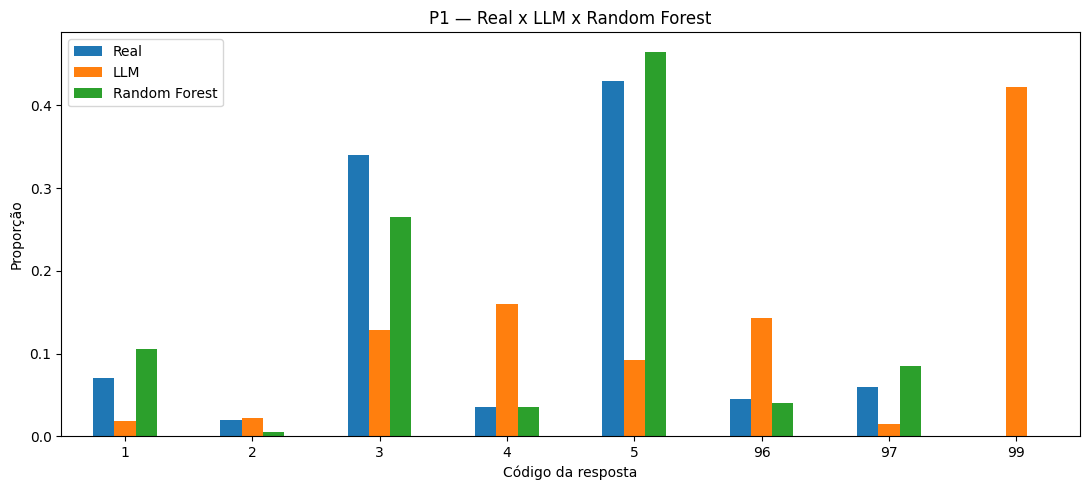

,Real,LLM,Random Forest
1,0.070,0.018333,0.105
2,0.020,0.021667,0.005
3,0.340,0.128333,0.265
4,0.035,0.160000,0.035
5,0.430,0.091667,0.465
96,0.045,0.143333,0.040
97,0.060,0.015000,0.085
99,0.000,0.421667,0.000


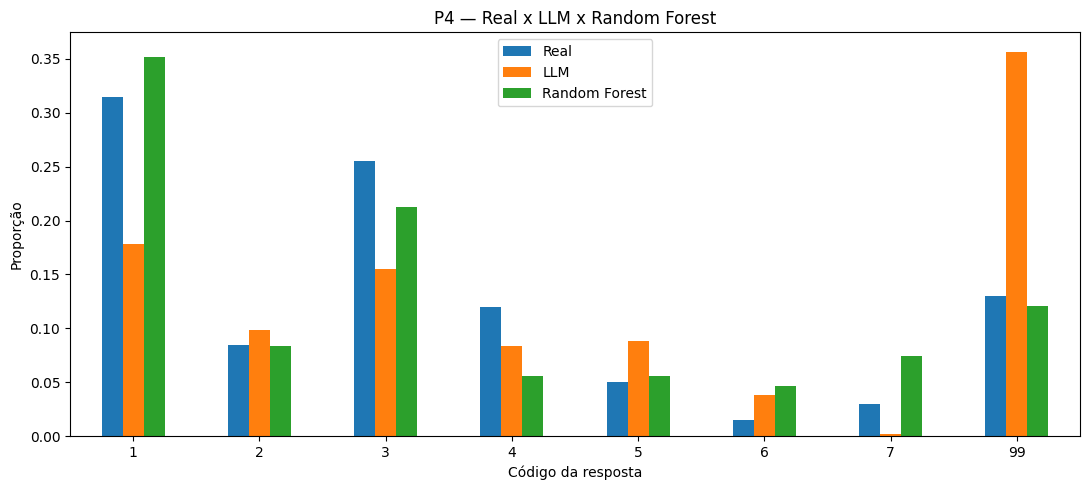

,Real,LLM,Random Forest
1,0.315,0.178333,0.351852
2,0.085,0.098333,0.083333
3,0.255,0.155000,0.212963
4,0.120,0.083333,0.055556
5,0.050,0.088333,0.055556
6,0.015,0.038333,0.046296
7,0.030,0.001667,0.074074
99,0.130,0.356667,0.120370


In [ ]:
# 15. Comparação distribucional
def mean_llm_distribution(llm_data, pred_col):
    dists = []
    for _, g in llm_data.groupby('seed'):
        dists.append(simple_distribution(g[pred_col].astype(int)))
    idx = sorted(set().union(*[set(d.index) for d in dists]))
    mat = pd.DataFrame([d.reindex(idx, fill_value=0) for d in dists])
    return mat.mean(axis=0)

real_p1 = simple_distribution(sample_p1['P1'].astype(int))
llm_dist_p1 = mean_llm_distribution(llm_p1, 'P1_LLM')
rf_dist_p1 = simple_distribution(pd.Series(pred_rf_p1).astype(int))
comp_p1 = plot_distribution_comparison(real_p1, llm_dist_p1, rf_dist_p1, 'P1 — Real x LLM x Random Forest')
display(comp_p1)

real_p4 = simple_distribution(sample_p4['P4'].astype(int))
llm_dist_p4 = mean_llm_distribution(llm_p4, 'P4_LLM')
rf_dist_p4 = simple_distribution(pd.Series(pred_rf_p4).astype(int))
comp_p4 = plot_distribution_comparison(real_p4, llm_dist_p4, rf_dist_p4, 'P4 — Real x LLM x Random Forest')
display(comp_p4)

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=comp_p4)

https://docs.google.com/spreadsheets/d/1LG3eCbZP5lFmRBlvNa4V1BVpBleMs5NwAi0yYp0Z3ME/edit#gid=0


In [ ]:
# 16. Métricas distribucionais consolidadas
def distribution_metrics(real, simulated, name):
    idx = sorted(set(real.index).union(simulated.index))
    real_v = real.reindex(idx, fill_value=0).values
    sim_v = simulated.reindex(idx, fill_value=0).values
    return {
        'modelo': name,
        'TVD': total_variation_distance(real, simulated),
        'JS_distance': js_distance(real, simulated),
        'MAE_proporcoes': np.mean(np.abs(real_v - sim_v))
    }

summary_dist = pd.DataFrame([
    distribution_metrics(real_p1, llm_dist_p1, 'LLM P1'),
    distribution_metrics(real_p1, rf_dist_p1, 'Random Forest P1'),
    distribution_metrics(real_p4, llm_dist_p4, 'LLM P4'),
    distribution_metrics(real_p4, rf_dist_p4, 'Random Forest P4'),
])
display(summary_dist)

,modelo,TVD,JS_distance,MAE_proporcoes
0,LLM P1,0.646667,0.636694,0.161667
1,Random Forest P1,0.095000,0.107434,0.027143
2,LLM P4,0.301667,0.289608,0.075417
3,Random Forest P4,0.117778,0.155152,0.029444


**Análise dos Resultados: Desempenho e Distribuição**

A análise das métricas revela o grande desafio que é simular a opinião pública e o comportamento humano utilizando modelos de linguagem (LLMs) compactos sem a aplicação de *Fine-Tuning*.

Em um nível individual, tanto o LLM quanto o Random Forest apresentaram acurácias relativamente baixas (variando entre 10% e 18%), o que é esperado, visto que a opinião humana carrega uma enorme subjetividade que não é totalmente explicada apenas por atributos sociodemográficos.

No entanto, a grande diferença aparece na análise distribucional (TVD e JS Distance). O objetivo ideal é que essas métricas sejam o mais próximas de zero possível:


*   Na Pergunta 1 (Tarefas Domésticas): O LLM apresentou um TVD alto de 0.646, o que demonstra que a distribuição de suas respostas divergiu fortemente da realidade. Em contrapartida, o modelo Random Forest capturou de forma excelente a tendência populacional, atingindo um TVD de apenas 0.095.
*   Na Pergunta 4 (Assédio, Mulheres): O LLM teve uma leve melhora em relação à primeira pergunta, reduzindo seu TVD para 0.301. Contudo, novamente o Random Forest foi superior na mimetização do comportamento coletivo, com um TVD de 0.117.

Estes resultados sugerem que, enquanto o Random Forest consegue mapear de forma puramente matemática a correlação dos dados na amostra, o LLM de 0.5B de parâmetros, na abordagem *Zero-Shot*, tende a convergir para os vieses inseridos durante o seu treinamento prévio, apresentando dificuldades para encarnar perfeitamente personas sociológicas específicas do contexto da cidade de São Paulo.

,variavel,importance_mean,importance_std
0,SEXO,0.0395,0.020549
2,FX_ID,0.0340,0.011790
5,RELIGIAO,0.0325,0.010062
10,REGIAO,0.0230,0.011874
4,RACA,0.0160,0.013928
1,IDADE,0.0160,0.012410
7,RENDA2,0.0070,0.010050
3,ESCOLARIDADE,0.0065,0.017755
8,OCUPACAO,0.0065,0.008382
9,CLASSE,-0.0035,0.010500


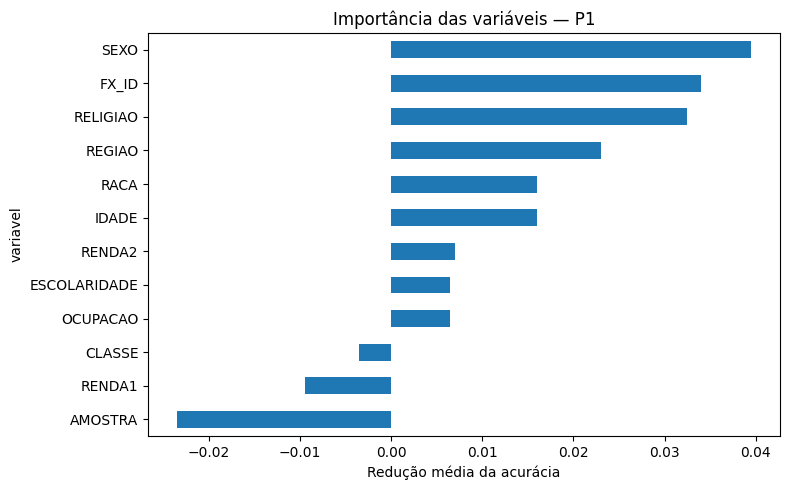

,variavel,importance_mean,importance_std
11,AMOSTRA,4.074074e-02,0.014463
2,FX_ID,3.611111e-02,0.020475
4,RACA,3.333333e-02,0.013225
1,IDADE,2.592593e-02,0.006929
5,RELIGIAO,6.481481e-03,0.013127
10,REGIAO,5.555556e-03,0.019066
6,RENDA1,1.851852e-03,0.010798
9,CLASSE,2.220446e-17,0.014930
0,SEXO,0.000000e+00,0.000000
3,ESCOLARIDADE,-8.333333e-03,0.009667


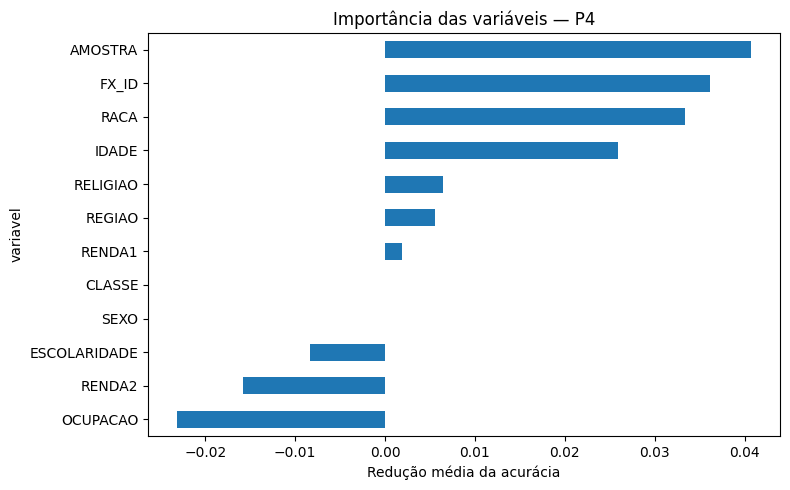

In [ ]:
# 17. Explicabilidade: permutation importance da Random Forest
def show_permutation_importance(model, X_test, y_test, title):
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=SEED, scoring='accuracy')
    imp = pd.DataFrame({
        'variavel': X_test.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std
    }).sort_values('importance_mean', ascending=False)
    display(imp)
    ax = imp.plot(kind='barh', x='variavel', y='importance_mean', figsize=(8, 5), legend=False)
    ax.set_title(title)
    ax.set_xlabel('Redução média da acurácia')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return imp

imp_p1 = show_permutation_importance(rf_p1, Xtest_p1, ytest_p1, 'Importância das variáveis — P1')
imp_p4 = show_permutation_importance(rf_p4, Xtest_p4, ytest_p4, 'Importância das variáveis — P4')

**Análise de Explicabilidade (*Permutation Importance*)**

Com o intuito de compreender quais fatores sociodemográficos mais impactam a formulação da opinião dos paulistanos, aplicamos a técnica de *Permutation Importance* sobre o modelo Random Forest.


*   Para a P1 (Divisão das Tarefas Domésticas): O modelo identificou de forma coesa com a literatura sociológica que as variáveis `SEXO` (0.0395), `FX_ID` (Faixa etária) e `RELIGIAO` são os preditores mais fortes. A percepção sobre quem executa as tarefas do lar é fortemente dividida pela questão de gênero e influenciada por perspectivas geracionais e religiosas.

*   Para a P4 (Risco de Assédio): Como esta pergunta foi direcionada exclusivamente às mulheres da amostra (anulando a variável genérica de gênero), o modelo identificou novos vetores de importância. As variáveis como `FX_ID` (Faixa de idade, 0.036), `RACA` (0.033) e `IDADE` destacaram-se significativamente. Faz sentido prático que fatores interseccionais, como ser uma mulher jovem e/ou negra, alterem sensivelmente a percepção sobre em quais locais (como ruas, trabalho ou transporte público) o risco de assédio é sentido com maior gravidade. A variável `AMOSTRA` também obteve destaque, indicando possíveis vieses ligados ao formato da coleta do dado (Papel, Web, Tablet).

In [ ]:
# 18. Salvamento dos resultados
Path('results').mkdir(exist_ok=True)
metrics_llm_p1.to_csv('results/metricas_llm_p1.csv', index=False)
metrics_llm_p4.to_csv('results/metricas_llm_p4.csv', index=False)
summary_dist.to_csv('results/metricas_distribucionais.csv', index=False)
comp_p1.to_csv('results/distribuicoes_p1.csv')
comp_p4.to_csv('results/distribuicoes_p4.csv')
imp_p1.to_csv('results/importancia_rf_p1.csv', index=False)
imp_p4.to_csv('results/importancia_rf_p4.csv', index=False)
print('Arquivos salvos na pasta results/')

Arquivos salvos na pasta results/


**Conclusão**

O projeto demonstrou um pipeline completo para a avaliação de LLMs na tarefa de simulação social baseada na pesquisa `CESOP 04833`. Concluímos que simular a opinião pública com alta precisão requer mais do que apenas a injeção de perfis sociodemográficos no *prompt*. Modelos LLM compactos (como o de 0.5B utilizado) operando em *Zero-Shot* não conseguiram superar algoritmos tradicionais supervisionados (Random Forest) no mapeamento das distribuições populacionais. Para trabalhos futuros, sugere-se a aplicação da técnica de *Fine-Tuning* (como LoRA) no LLM com base em pesquisas anteriores, ou a utilização de modelos com mais parâmetros (ex: 8B ou superiores) para avaliar se o aumento da capacidade cognitiva se traduz em melhor adoção de personas sociais.


---


**Referências Bibliográficas**

ARGENTO, C. et al. Simulating Public Opinion: Comparing Distributional and Individual-Level Predictions from LLMs and Random Forests. 2024.

CESOP – Centro de Estudos de Opinião Pública. Percepção dos paulistanos acerca de questões relacionadas às mulheres (Pesquisa 04833). Unicamp.

HUGGING FACE. Transformers Documentation. Disponível em: https://huggingface.co/docs/transformers/index.

PEDREGOSA, F. et al. Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, p. 2825-2830, 2011.